<a href="https://colab.research.google.com/github/ferchoobarba/Lupus_IA_Proyect/blob/main/LupusIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TALLER - RETO: Diagnóstico de Enfermedades en Cultivos de Tomate (Agro Tech)

Micaela Garau -
Fernando Barba 55226017

PASO 1: Ingesta y Filtrado del Dataset Médico



In [1]:
import os
import shutil
import warnings
from PIL import Image, ImageFile
from sklearn.model_selection import train_test_split

# Evita que el script falle por imágenes médicas pesadas o metadatos rotos
warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

# 1. Configuración de Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# 2. Descarga y Descompresión (Fresca)
print("📥 1. Descargando dataset médico...")
!kaggle datasets download -d arindamsaha07/skin-diesease-image-dataset -p /content/
print("📦 2. Descomprimiendo...")
!unzip -q /content/skin-diesease-image-dataset.zip -d /content/raw_dataset/

# Palabras clave súper flexibles (para cazar las carpetas ocultas)
keywords = {
    'lupus': 'Lupus',
    'rosacea': 'Rosacea',
    'seborrheic': 'Imitadores_Benignos',
    'normal': 'Piel_Sana',
    'healthy': 'Piel_Sana',
    'clear': 'Piel_Sana'
}

base_dir = '/content/LupusAI_Dataset'
fases = ['train', 'val', 'test']

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

for fase in fases:
    for clase_nueva in set(keywords.values()):
        os.makedirs(os.path.join(base_dir, fase, clase_nueva), exist_ok=True)

print("\n🔍 3. Buscando carpetas dinámicamente en el dataset extraído...")
origen_base = '/content/raw_dataset'
imagenes_validas = {clase: [] for clase in set(keywords.values())}
carpetas_encontradas = []

# Búsqueda profunda
for root, dirs, files in os.walk(origen_base):
    for d in dirs:
        dir_lower = d.lower()
        for kw, clase_dest in keywords.items():
            if kw in dir_lower:
                ruta_clase = os.path.join(root, d)
                if ruta_clase not in carpetas_encontradas:
                    carpetas_encontradas.append(ruta_clase)
                    print(f"   ✅ Encontrada carpeta: '{d}' -> Mapeada a: [{clase_dest}]")

                    archivos = [f for f in os.listdir(ruta_clase) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
                    for arch in archivos:
                        ruta_arch = os.path.join(ruta_clase, arch)
                        try:
                            with Image.open(ruta_arch) as img:
                                img.verify()
                            imagenes_validas[clase_dest].append(ruta_arch)
                        except:
                            continue

print("\n⚙️ 4. Realizando partición estratificada (Train/Val/Test)...")
conteo_final = {fase: {clase: 0 for clase in set(keywords.values())} for fase in fases}

for clase, rutas in imagenes_validas.items():
    rutas = list(set(rutas)) # Eliminar duplicados
    total = len(rutas)
    print(f"➡️ Total imágenes válidas cazadas para {clase}: {total}")

    if total < 10:
        print(f"   ⚠️ ADVERTENCIA: Aún hay 0 o muy pocas imágenes para {clase}.")
        continue

    train_rutas, val_test_rutas = train_test_split(rutas, test_size=0.30, random_state=42)
    val_rutas, test_rutas = train_test_split(val_test_rutas, test_size=0.50, random_state=42)

    asignaciones = {'train': train_rutas, 'val': val_rutas, 'test': test_rutas}

    for fase, rutas_fase in asignaciones.items():
        for ruta_origen in rutas_fase:
            nombre_arch = os.path.basename(ruta_origen)
            nombre_unico = os.path.basename(os.path.dirname(ruta_origen)) + "_" + nombre_arch
            ruta_destino = os.path.join(base_dir, fase, clase, nombre_unico)

            shutil.copy(ruta_origen, ruta_destino)
            conteo_final[fase][clase] += 1

print("\n🧹 5. Limpiando archivos residuales pesados...")
!rm /content/skin-diesease-image-dataset.zip
!rm -rf /content/raw_dataset/

print("\n🚀 --- RESUMEN DEL DATASET LUPUS AI ---")
for fase in fases:
    print(f"\n📁 Conjunto de {fase.upper()}:")
    for clase, cantidad in conteo_final[fase].items():
        print(f"   - {clase}: {cantidad} imágenes")

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
📥 1. Descargando dataset médico...
Dataset URL: https://www.kaggle.com/datasets/arindamsaha07/skin-diesease-image-dataset
License(s): unknown
100% 898M/898M [00:08<00:00, 109MB/s] 

📦 2. Descomprimiendo...

🔍 3. Buscando carpetas dinámicamente en el dataset extraído...
   ✅ Encontrada carpeta: 'Rosacea' -> Mapeada a: [Rosacea]
   ✅ Encontrada carpeta: 'Lupus' -> Mapeada a: [Lupus]
   ✅ Encontrada carpeta: 'Rosacea' -> Mapeada a: [Rosacea]
   ✅ Encontrada carpeta: 'Lupus' -> Mapeada a: [Lupus]

⚙️ 4. Realizando partición estratificada (Train/Val/Test)...
➡️ Total imágenes válidas cazadas para Imitadores_Benignos: 0
   ⚠️ ADVERTENCIA: Aún hay 0 o muy pocas imágenes para Imitadores_Benignos.
➡️ Total imágenes válidas cazadas para Rosacea: 528
➡️ Total imágenes válidas cazadas para Lupus: 534
➡️ Total imágenes válidas cazadas para Piel_Sana: 0
   ⚠️ ADVERTENC

PASO 2: Data Augmentation Clínico y DataLoaders (TensorFlow 2.x)

⚙️ 1. Construyendo DataLoaders hiper-optimizados (tf.data)...
Found 742 files belonging to 4 classes.
Found 159 files belonging to 4 classes.
Found 161 files belonging to 4 classes.
✅ Clases detectadas por TensorFlow: ['Imitadores_Benignos', 'Lupus', 'Piel_Sana', 'Rosacea']

👁️ 2. Generando previsualización de datos aumentados...


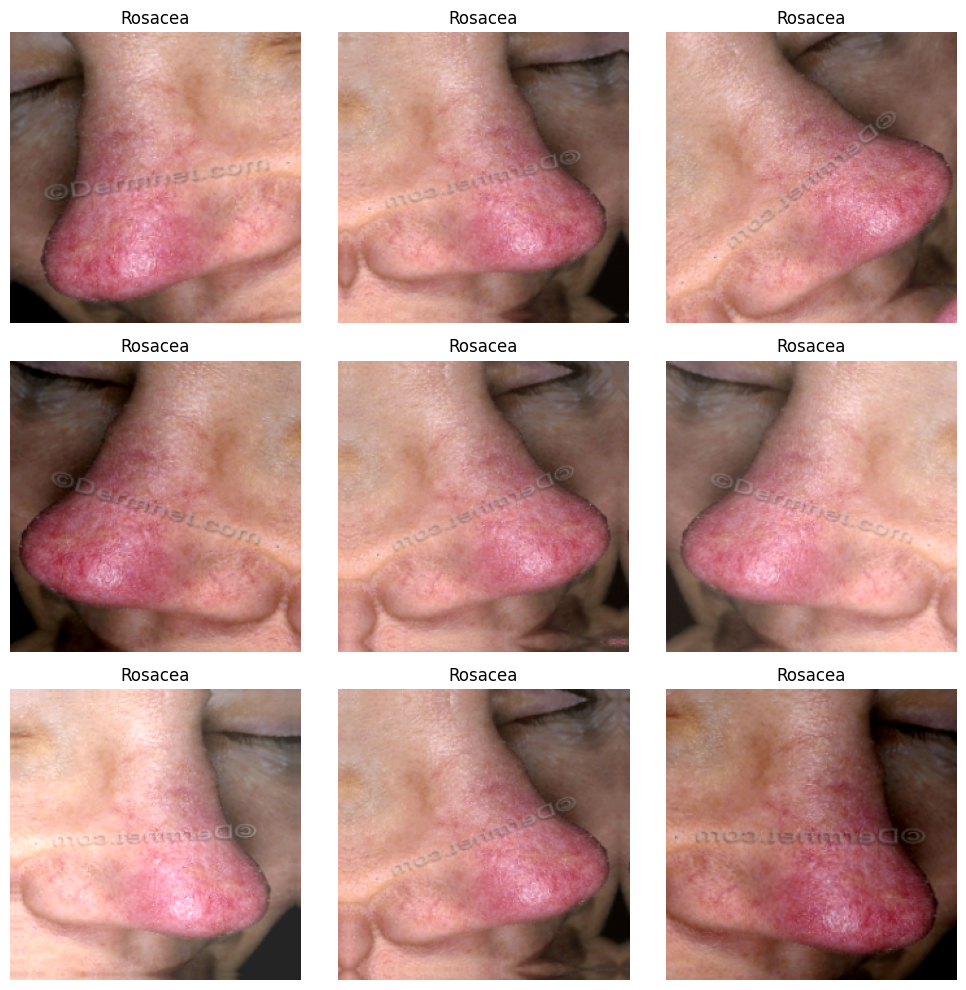

In [4]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 1. Configuración de Hiperparámetros base
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
BASE_DIR = '/content/LupusAI_Dataset'

print("⚙️ 1. Construyendo DataLoaders hiper-optimizados (tf.data)...")

# 2. Carga directa a tensores
train_dataset = tf.keras.utils.image_dataset_from_directory(
    f'{BASE_DIR}/train',
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical' # categorical para obtener probabilidades por clase
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    f'{BASE_DIR}/val',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical'
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    f'{BASE_DIR}/test',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    label_mode='categorical'
)

class_names = train_dataset.class_names
print(f"✅ Clases detectadas por TensorFlow: {class_names}")

# 3. Optimización de memoria en caché (Autotune)
# Esto carga las imágenes en la RAM para que el entrenamiento no tenga cuellos de botella
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

# 4. Pipeline de Data Augmentation Clínico
# Estas transformaciones ocurren 'on-the-fly' (al vuelo) durante cada epoch
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal"), # El rostro es simétrico
  layers.RandomRotation(0.15),     # Pequeñas inclinaciones de cabeza
  layers.RandomZoom(0.1),          # Acercamientos de cámara variados
  layers.RandomContrast(0.2),      # Simular distintos tonos de piel
  layers.RandomBrightness(0.2),    # Simular flash vs luz natural
], name="clinical_augmentation_layer")

# 5. Visualización del Augmentation (Prueba de cordura)
print("\n👁️ 2. Generando previsualización de datos aumentados...")
plt.figure(figsize=(10, 10))
for images, labels in train_dataset.take(1): # Tomar un solo batch
    # Tomar la primera imagen del batch y aplicarle el aumento 9 veces
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(images[0], 0), training=True)
        # Mostrar la imagen
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        # Mostrar a qué clase pertenece
        class_idx = tf.argmax(labels[0]).numpy()
        plt.title(class_names[class_idx])
        plt.axis("off")
plt.tight_layout()
plt.show()

PASO 3: Ensamblaje de la Arquitectura EfficientNetB0

In [5]:
print("🧠 1. Construyendo Arquitectura Mejorada (V1.5)...")

# 1. El Cerebro Base (ImageNet)
base_model = tf.keras.applications.EfficientNetB0(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

# Congelamos los pesos base para la Fase 1 del entrenamiento
base_model.trainable = False

print("🏗️ 2. Ensamblando el clasificador con regularización severa...")

# 2. Construcción de la Arquitectura
inputs = tf.keras.Input(shape=IMG_SIZE + (3,))

# Pasamos por el Data Augmentation del Paso 2
x = data_augmentation(inputs)

# Extraemos características con la base congelada
x = base_model(x, training=False)

# Aplastamiento y Normalización
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)

# UPGRADE 1: Dropout al 50% (Prevención drástica de memorización)
x = layers.Dropout(0.5)(x)

# Capa de salida multiclase
num_classes = len(class_names)
outputs = layers.Dense(num_classes, activation='softmax')(x)

# Ensamblamos el modelo V1.5
model = tf.keras.Model(inputs, outputs, name="LupusAI_EfficientNet_V1.5")

print("⚙️ 3. Compilando con Label Smoothing (Calibración Clínica)...")

# UPGRADE 2: Label Smoothing al 10%
# Esto fuerza a la IA a "dudar" un poco, mejorando enormemente el AUC en casos difíciles
loss_fn = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1)

initial_learning_rate = 0.0001

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=initial_learning_rate),
    loss=loss_fn,
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Imprimir el resumen
model.summary()

🧠 1. Construyendo Arquitectura Mejorada (V1.5)...
🏗️ 2. Ensamblando el clasificador con regularización severa...
⚙️ 3. Compilando con Label Smoothing (Calibración Clínica)...


Model: "LupusAI_EfficientNet_V1.5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ clinical_augmentation_layer     │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         5,124 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,059,815 (15.49 MB)

 Trainable params: 7,684 (30.02 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

PASO 4: Entrenamiento, Callbacks y Curvas Clínicas

🚀 1. INICIANDO ETAPA 4.1: Calentamiento de la Cabeza (Warmup)...
Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 22s 329ms/step - accuracy: 0.2978 - auc: 0.5655 - loss: 2.1535 - precision: 0.3042 - recall: 0.2345 - val_accuracy: 0.2830 - val_auc: 0.5426 - val_loss: 1.4938 - val_precision: 0.3000 - val_recall: 0.0566
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - accuracy: 0.3140 - auc: 0.5675 - loss: 2.1238 - precision: 0.3265 - recall: 0.2561 - val_accuracy: 0.3711 - val_auc: 0.6238 - val_loss: 1.3984 - val_precision: 0.4634 - val_recall: 0.1195
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3639 - auc: 0.6235 - loss: 1.8857 - precision: 0.4025 - recall: 0.3086 - val_accuracy: 0.4780 - val_auc: 0.6928 - val_loss: 1.3105 - val_precision: 0.5610 - val_recall: 0.1447
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - accuracy: 0.3693 - auc: 0.6275 - loss: 1.8783 - precision: 0.3908 - recall: 0.2992 - val_accuracy: 0.5220 - val_auc: 0.7435 - val_loss: 1.2396 - val_precision: 

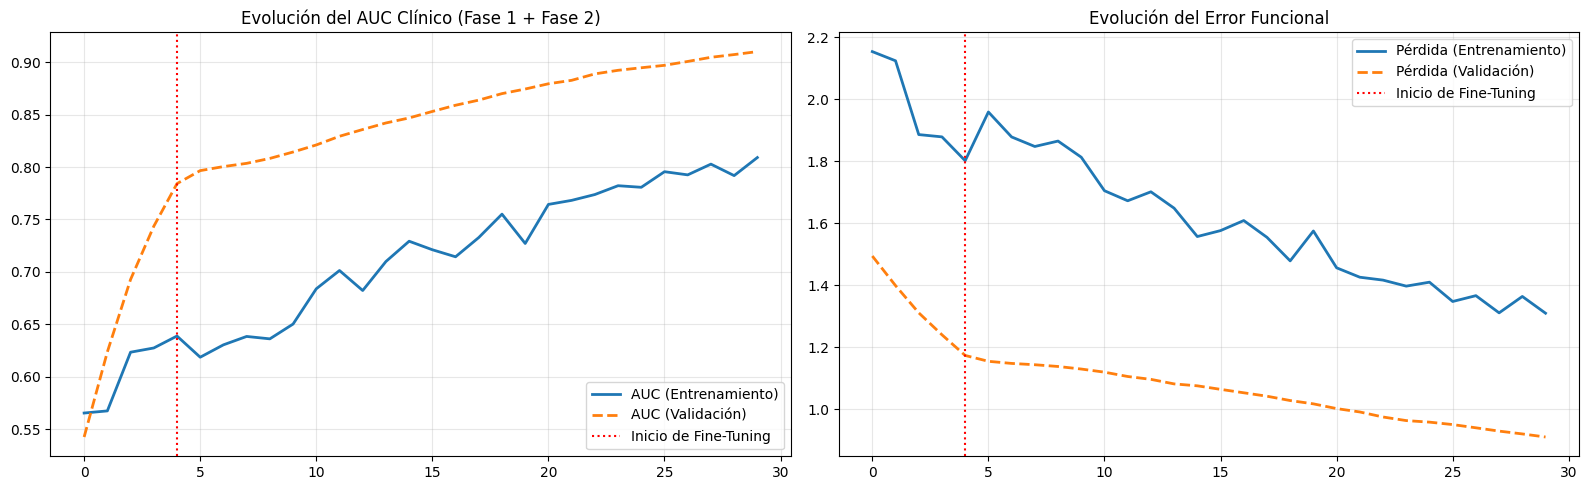

In [6]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf

print("🚀 1. INICIANDO ETAPA 4.1: Calentamiento de la Cabeza (Warmup)...")
# Entrenamos solo la cabeza por 5 épocas para estabilizar los gradientes iniciales

history_phase1 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=5,
    verbose=1
)

print("\n🔓 2. INICIANDO ETAPA 4.2: Fine-Tuning Profundo (Descongelamiento Gradual)...")

# Descongelamos el modelo base para permitir la adaptación fina
base_model = model.get_layer('efficientnetb0')
base_model.trainable = True

# Volvemos a congelar las capas inferiores (bordes/colores simples)
# Habilitamos únicamente las últimas 30 capas para sintonización dermatológica
for layer in base_model.layers[:-30]:
    layer.trainable = False

print(f"   -> Parámetros/Capas entrenables en la base: {len(base_model.trainable_variables)}")

# Re-compilación obligatoria con Tasa de Aprendizaje Microscópica
# Si usamos una tasa alta aquí, destruiremos el conocimiento previo del modelo
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

# Configuración de los Escudos de Control de Keras 3
checkpoint_path = '/content/LupusAI_Checkpoints/mejor_modelo_lupus_rosacea.weights.h5'

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path, monitor='val_auc', mode='max',
        save_best_only=True, save_weights_only=True, verbose=1
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc', mode='max', patience=6, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7, verbose=1
    )
]

# Entrenamiento de sintonización fina
history_phase2 = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=25,
    callbacks=callbacks,
    verbose=1
)

print("\n✅ ENTRENAMIENTO PROFESIONAL FINALIZADO. Pesos óptimos consolidados.")

# ---------------------------------------------------------------------------
print("\n📊 3. Generando las Curvas de Aprendizaje Combinadas...")

def plot_fine_tuning_metrics(h1, h2):
    # Fusionamos secuencialmente las métricas de ambas etapas de entrenamiento
    auc = h1.history['auc'] + h2.history['auc']
    val_auc = h1.history['val_auc'] + h2.history['val_auc']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    plt.figure(figsize=(16, 5))
    warmup_end = len(h1.history['auc']) - 1

    # Gráfica de Área Bajo la Curva (AUC)
    plt.subplot(1, 2, 1)
    plt.plot(auc, label='AUC (Entrenamiento)', linewidth=2)
    plt.plot(val_auc, label='AUC (Validación)', linewidth=2, linestyle='--')
    plt.axvline(x=warmup_end, color='red', linestyle=':', label='Inicio de Fine-Tuning')
    plt.legend(loc='lower right')
    plt.title('Evolución del AUC Clínico (Fase 1 + Fase 2)')
    plt.grid(True, alpha=0.3)

    # Gráfica del Error (Loss) con Label Smoothing
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Pérdida (Entrenamiento)', linewidth=2)
    plt.plot(val_loss, label='Pérdida (Validación)', linewidth=2, linestyle='--')
    plt.axvline(x=warmup_end, color='red', linestyle=':', label='Inicio de Fine-Tuning')
    plt.legend(loc='upper right')
    plt.title('Evolución del Error Funcional')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_fine_tuning_metrics(history_phase1, history_phase2)

PASO 5: El Motor de Interpretabilidad (Grad-CAM)

🔬 1. Generando Radiografía Neuronal (Grad-CAM)...


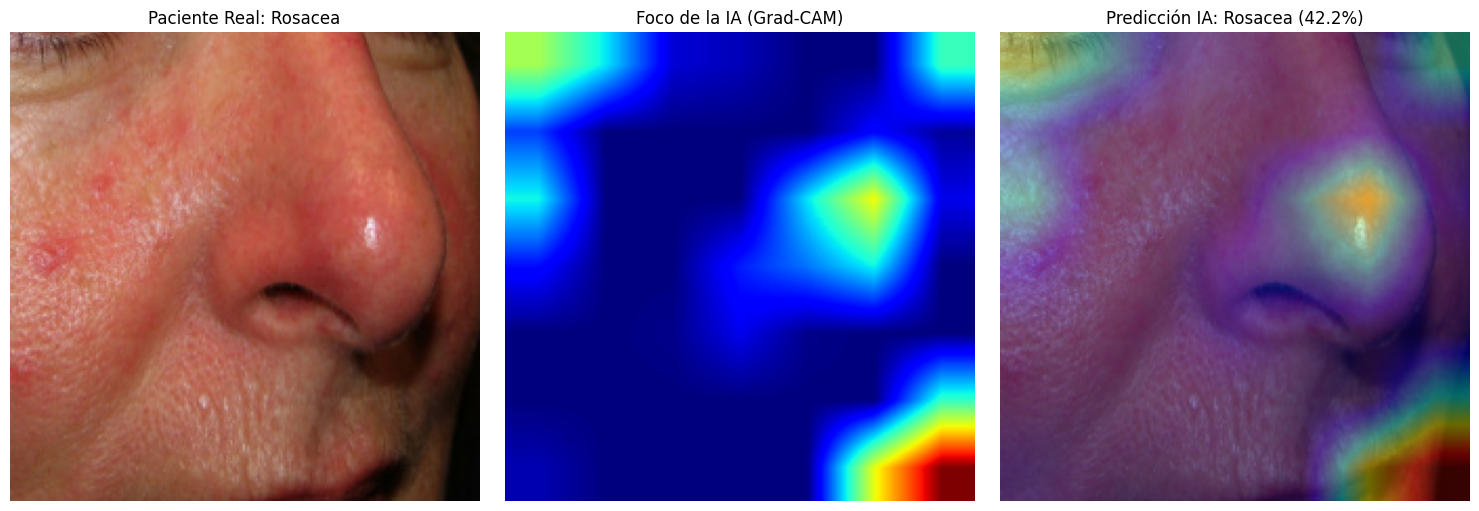

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf

print("🔬 1. Generando Radiografía Neuronal (Grad-CAM)...")

# 1. Obtener un paciente de prueba al azar
for images, labels in test_dataset.shuffle(100).take(1):
    img_array = images[0:1]
    img_visual = img_array[0].numpy().astype("uint8")
    real_label = class_names[tf.argmax(labels[0]).numpy()]
    break

# 2. Configurar el modelo para extraer gradientes
base_model = model.get_layer('efficientnetb0')
last_conv_layer_name = 'top_activation'

feature_extractor = tf.keras.Model(
    inputs=base_model.inputs,
    outputs=base_model.get_layer(last_conv_layer_name).output
)

# Reconstruir la cabeza clasificadora
classifier_input = tf.keras.Input(shape=feature_extractor.output.shape[1:])
x = classifier_input
for layer in model.layers[3:]:
    x = layer(x, training=False)
classifier = tf.keras.Model(inputs=classifier_input, outputs=x)

# 3. Calcular qué píxeles importan más con GradientTape
with tf.GradientTape() as tape:
    last_conv_layer_output = feature_extractor(img_array)
    tape.watch(last_conv_layer_output)

    preds = classifier(last_conv_layer_output)
    pred_idx = tf.argmax(preds[0])
    class_channel = preds[:, pred_idx]
    pred_label = class_names[pred_idx.numpy()]
    confidence = preds[0][pred_idx] * 100

# 4. Renderizar el Mapa de Calor (Heatmap)
grads = tape.gradient(class_channel, last_conv_layer_output)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

last_conv_layer_output = last_conv_layer_output.numpy()[0]
pooled_grads = pooled_grads.numpy()

for i in range(pooled_grads.shape[-1]):
    last_conv_layer_output[:, :, i] *= pooled_grads[i]

heatmap = np.mean(last_conv_layer_output, axis=-1)
heatmap = np.maximum(heatmap, 0) / np.max(heatmap)

heatmap_resized = cv2.resize(heatmap, (224, 224))
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

# EL FIX: cv2.COLOR_BGR2RGB (sin el "MAP")
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

superimposed_img = cv2.addWeighted(img_visual, 0.6, heatmap_color, 0.4, 0)

# 5. Visualización Médica
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(img_visual)
plt.title(f"Paciente Real: {real_label}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_resized, cmap='jet')
plt.title("Foco de la IA (Grad-CAM)")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img)
plt.title(f"Predicción IA: {pred_label} ({confidence:.1f}%)")
plt.axis("off")

plt.tight_layout()
plt.show()

UPGRADE: PASO 6 (Fusión Multimodal - IA Visual + Síntomas)

In [8]:
import numpy as np
import tensorflow as tf

print("⚙️ 1. Compilando el Motor de Triaje Híbrido (Multimodal)...")

class LupusAI_Triage_Engine:
    def __init__(self, vision_model, class_labels):
        self.vision_model = vision_model
        self.class_labels = class_labels
        # Calibración del algoritmo: 70% peso a la IA Visual, 30% a los Síntomas
        self.weight_vision = 0.70
        self.weight_clinical = 0.30

    def calculate_clinical_risk(self, patient_data):
        # Motor de reglas basado en marcadores tempranos del ACR
        score = 0.0
        max_score = 40.0 # Puntaje máximo de triaje en primera línea

        if patient_data.get('fotosensibilidad', False): score += 15.0
        if patient_data.get('ulceras_bucales', False): score += 10.0
        if patient_data.get('dolor_articular', False): score += 10.0
        if patient_data.get('fatiga_extrema', False): score += 5.0

        return min(score / max_score, 1.0) # Retorna un riesgo de 0.0 a 1.0

    def generate_report(self, img_tensor, patient_data):
        # 1. Inferencia de Visión Artificial (El modelo que entrenaste)
        preds = self.vision_model.predict(img_tensor, verbose=0)[0]
        lupus_idx = self.class_labels.index('Lupus')
        vision_risk = preds[lupus_idx]

        # 2. Inferencia Clínica (Síntomas tabulares)
        clinical_risk = self.calculate_clinical_risk(patient_data)

        # 3. Fusión Multimodal (Weighted Average)
        final_risk = (vision_risk * self.weight_vision) + (clinical_risk * self.weight_clinical)

        # 4. Generación de Alerta de Triaje
        alerta = "BAJA (Manejo ambulatorio)"
        if final_risk >= 0.75:
            alerta = "🚨 CRÍTICA (Derivación URGENTE a Reumatología)"
        elif final_risk >= 0.45:
            alerta = "⚠️ MODERADA (Solicitar laboratorios ANA/Anti-DNA)"

        # 5. Imprimir UI de la Consola
        print("\n" + "="*55)
        print("🩺 REPORTE DE TRIAJE LUPUS AI (VERSIÓN 2.0) 🩺")
        print("="*55)
        print(f"👤 Paciente - Edad: {patient_data.get('edad')} | Sexo: {patient_data.get('sexo')}")
        print(f"📸 Riesgo Visual (TensorFlow):    {vision_risk*100:>5.1f}%")
        print(f"📋 Riesgo Clínico (Síntomas):      {clinical_risk*100:>5.1f}%")
        print("-" * 55)
        print(f"🔴 RIESGO FINAL FUSIONADO:         {final_risk*100:>5.1f}%")
        print(f"📋 DECISIÓN: {alerta}")
        print("="*55)
        return final_risk

print("🚀 2. Instanciando el motor y conectándolo a tu Red Neuronal...")
# Usamos el modelo que está actualmente cargado en tu memoria RAM
lupus_engine = LupusAI_Triage_Engine(vision_model=model, class_labels=class_names)

print("🧪 3. Simulando pacientes en el consultorio rural...")

# Tomamos una imagen al azar del dataset de prueba (simulando la foto del médico)
for images, labels in test_dataset.shuffle(50).take(1):
    img_tensor = images[0:1]
    break

# --- CASO CLÍNICO A: Paciente con Síntomas ---
paciente_A = {
    'edad': 24, 'sexo': 'Femenino',
    'fotosensibilidad': True,
    'ulceras_bucales': False,
    'dolor_articular': True,
    'fatiga_extrema': True
}
print("\n>>> Procesando Caso Clínico A (Con síntomas)...")
lupus_engine.generate_report(img_tensor, paciente_A)

# --- CASO CLÍNICO B: Paciente Asintomático (Misma foto, diferentes datos) ---
paciente_B = {
    'edad': 35, 'sexo': 'Masculino',
    'fotosensibilidad': False,
    'ulceras_bucales': False,
    'dolor_articular': False,
    'fatiga_extrema': False
}
print("\n>>> Procesando Caso Clínico B (Sin síntomas)...")
lupus_engine.generate_report(img_tensor, paciente_B)

⚙️ 1. Compilando el Motor de Triaje Híbrido (Multimodal)...
🚀 2. Instanciando el motor y conectándolo a tu Red Neuronal...
🧪 3. Simulando pacientes en el consultorio rural...

>>> Procesando Caso Clínico A (Con síntomas)...

🩺 REPORTE DE TRIAJE LUPUS AI (VERSIÓN 2.0) 🩺
👤 Paciente - Edad: 24 | Sexo: Femenino
📸 Riesgo Visual (TensorFlow):     23.6%
📋 Riesgo Clínico (Síntomas):       75.0%
-------------------------------------------------------
🔴 RIESGO FINAL FUSIONADO:          39.0%
📋 DECISIÓN: BAJA (Manejo ambulatorio)

>>> Procesando Caso Clínico B (Sin síntomas)...

🩺 REPORTE DE TRIAJE LUPUS AI (VERSIÓN 2.0) 🩺
👤 Paciente - Edad: 35 | Sexo: Masculino
📸 Riesgo Visual (TensorFlow):     23.6%
📋 Riesgo Clínico (Síntomas):        0.0%
-------------------------------------------------------
🔴 RIESGO FINAL FUSIONADO:          16.5%
📋 DECISIÓN: BAJA (Manejo ambulatorio)


np.float32(0.16507466)